In [2]:
import pandas as pd

df = pd.read_csv('data/flight_delays.csv', nrows=100000)
print(df.shape)
print(df.columns.tolist())
print(df.head())

(100000, 16)
['FlightID', 'Airline', 'FlightNumber', 'Origin', 'Destination', 'ScheduledDeparture', 'ActualDeparture', 'ScheduledArrival', 'ActualArrival', 'DelayMinutes', 'DelayReason', 'Cancelled', 'Diverted', 'AircraftType', 'TailNumber', 'Distance']
   FlightID    Airline  FlightNumber Origin Destination ScheduledDeparture  \
0         1     United          4558    ORD         MIA   2024-09-01 08:11   
1         2      Delta          8021    LAX         MIA   2024-09-01 10:25   
2         3  Southwest          7520    DFW         SFO   2024-09-01 16:53   
3         4      Delta          2046    ORD         BOS   2024-09-01 14:44   
4         5      Delta          6049    LAX         SEA   2024-09-01 01:51   

    ActualDeparture  ScheduledArrival     ActualArrival  DelayMinutes  \
0  2024-09-01 08:30  2024-09-01 12:11  2024-09-01 12:19             8   
1  2024-09-01 10:41  2024-09-01 13:25  2024-09-01 13:27             2   
2  2024-09-01 17:05  2024-09-01 17:53  2024-09-01 18:07   

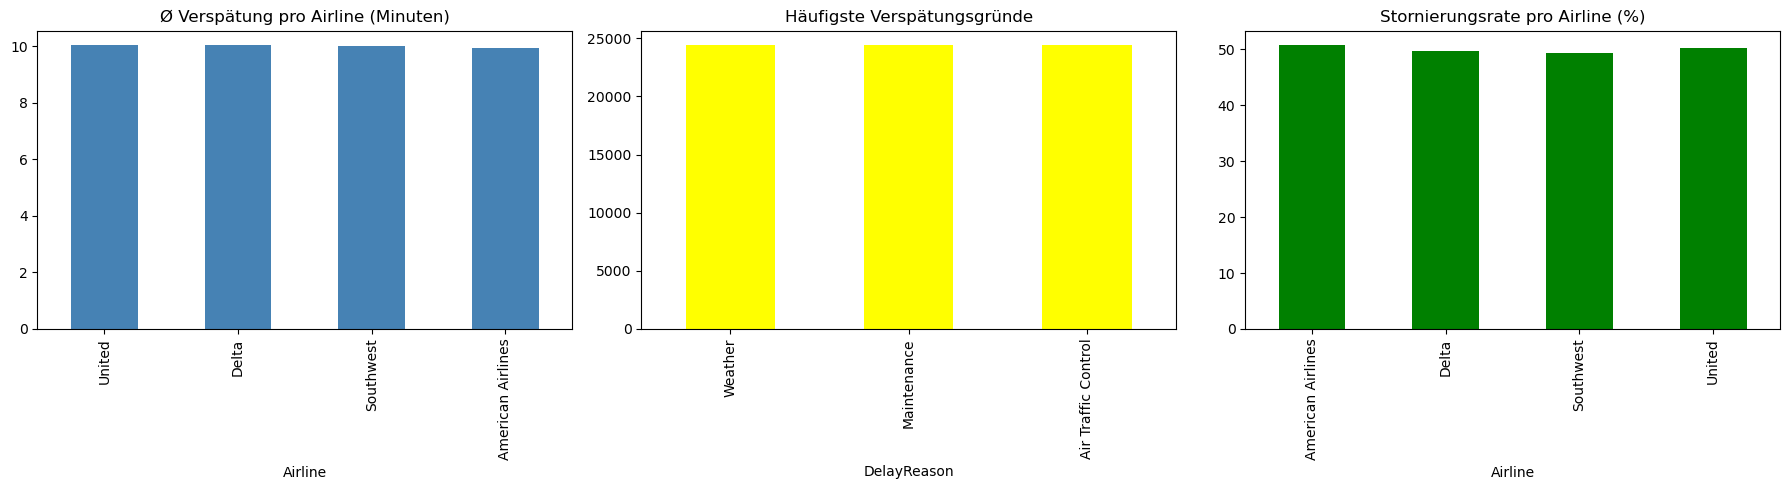

In [8]:
import matplotlib.pyplot as plt

# 1. Durchschnittliche Verspätung pro Airline
avg_delay = df.groupby('Airline')['DelayMinutes'].mean().sort_values(ascending=False)

# 2. Häufigste Verspätungsgründe
delay_reasons = df['DelayReason'].value_counts()

# 3. Anteil stornierter Flüge pro Airline
cancelled = df.groupby('Airline')['Cancelled'].mean() * 100

# Grafiken
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

avg_delay.plot(kind='bar', ax=axes[0], color='steelblue', title='Ø Verspätung pro Airline (Minuten)')
delay_reasons.plot(kind='bar', ax=axes[1], color='yellow', title='Häufigste Verspätungsgründe')
cancelled.plot(kind='bar', ax=axes[2], color='green', title='Stornierungsrate pro Airline (%)')

plt.tight_layout()
plt.savefig('analysis.png')
plt.show()